# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Telco-Customer  Dataset](https://www.kaggle.com/datasets/itszubi/customer-churn-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

/kaggle/input/datasets/itszubi/customer-churn-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## last Five row

In [4]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


## Shape of our dataset

In [5]:
df.shape

(7043, 21)

## List out all columns

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Check Null Value

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

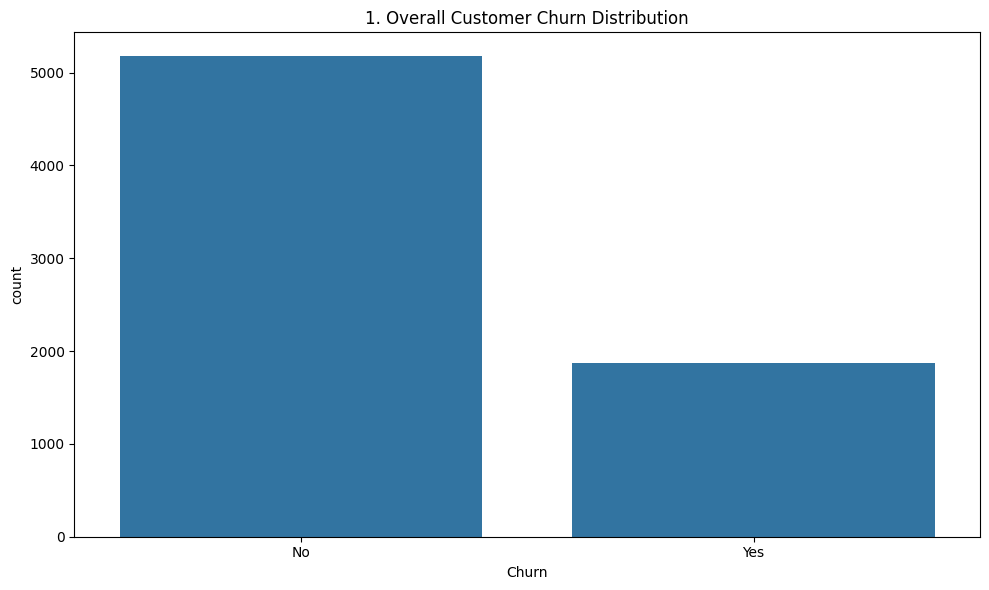

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Churn')
plt.title(f'{plot_no}. Overall Customer Churn Distribution')
show_fig()
plot_no += 1

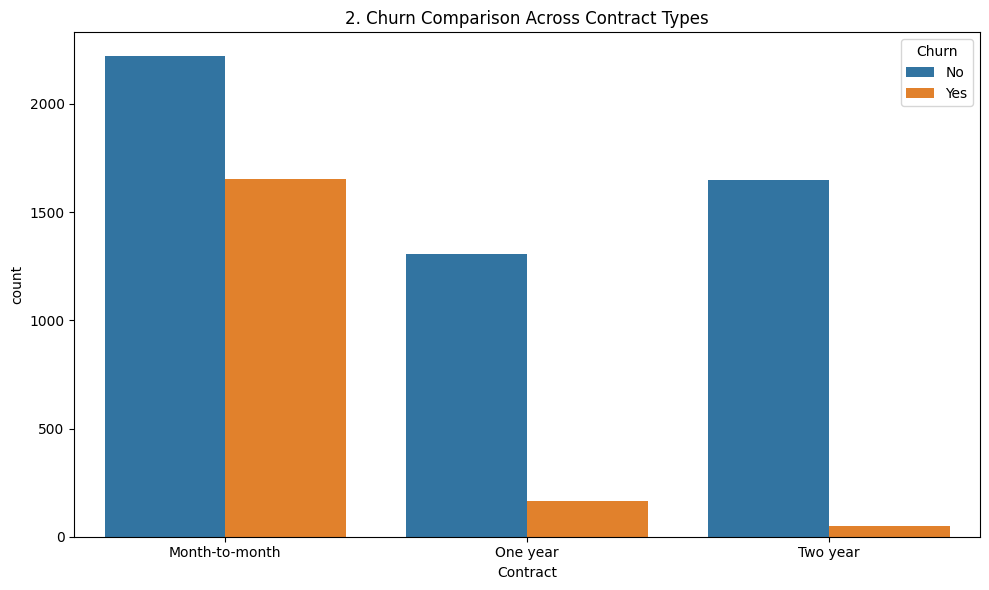

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title(f'{plot_no}. Churn Comparison Across Contract Types')
show_fig()
plot_no += 1

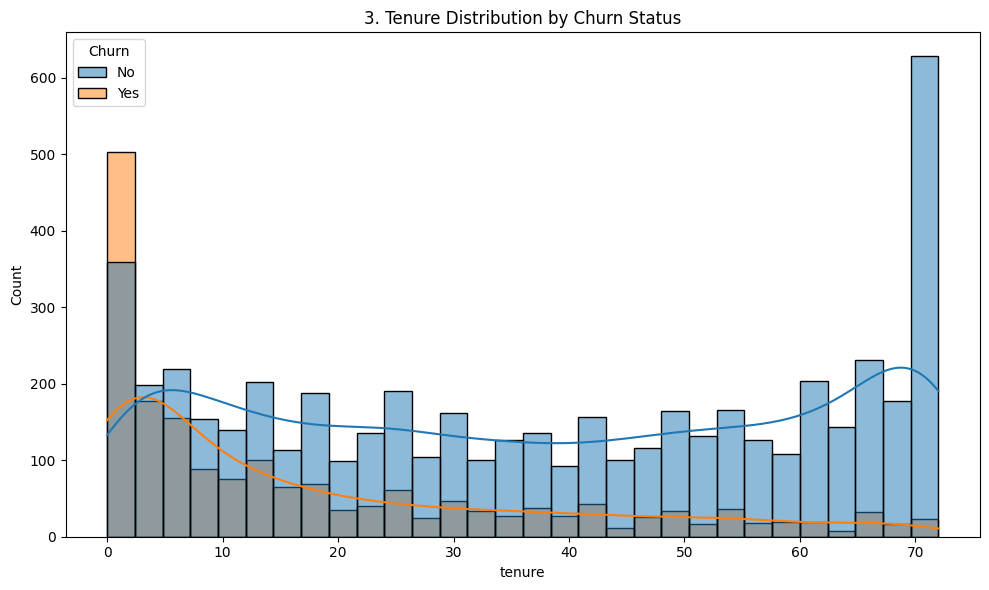

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30)
plt.title(f'{plot_no}. Tenure Distribution by Churn Status')
show_fig()
plot_no += 1

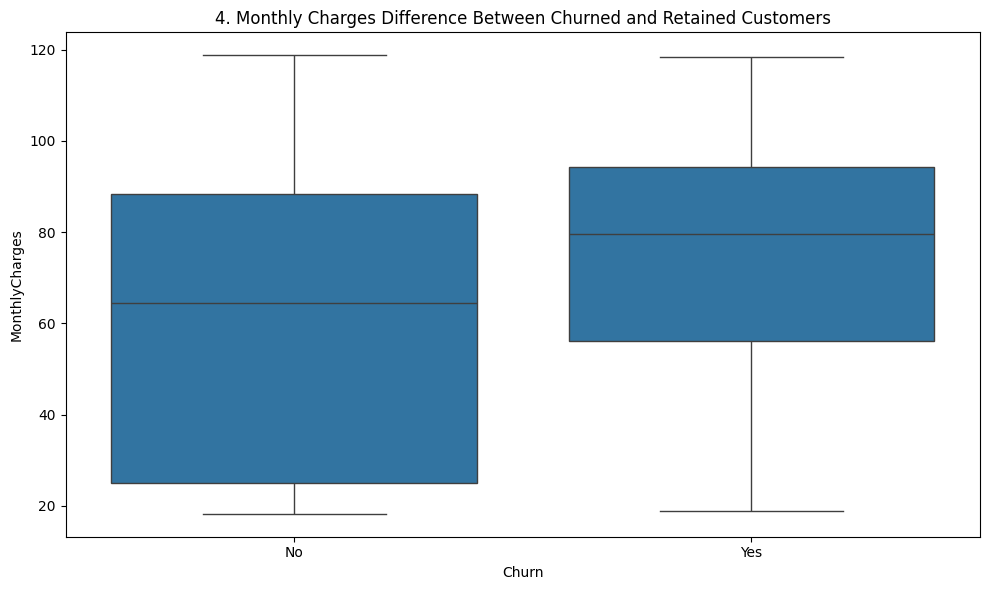

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title(f'{plot_no}. Monthly Charges Difference Between Churned and Retained Customers')
show_fig()
plot_no += 1

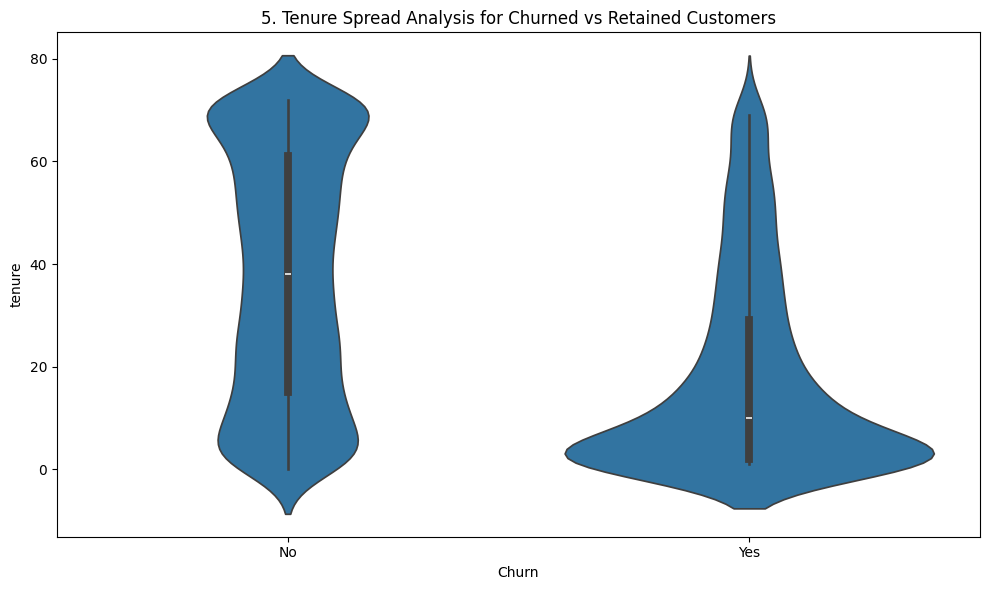

In [17]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Churn', y='tenure')
plt.title(f'{plot_no}. Tenure Spread Analysis for Churned vs Retained Customers')
show_fig()
plot_no += 1

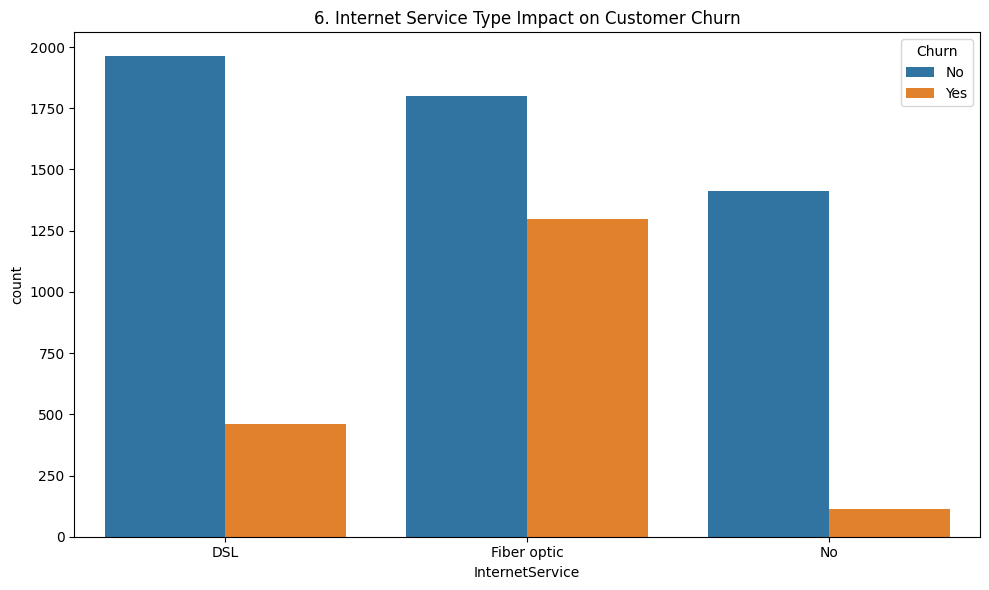

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title(f'{plot_no}. Internet Service Type Impact on Customer Churn')
show_fig()
plot_no += 1

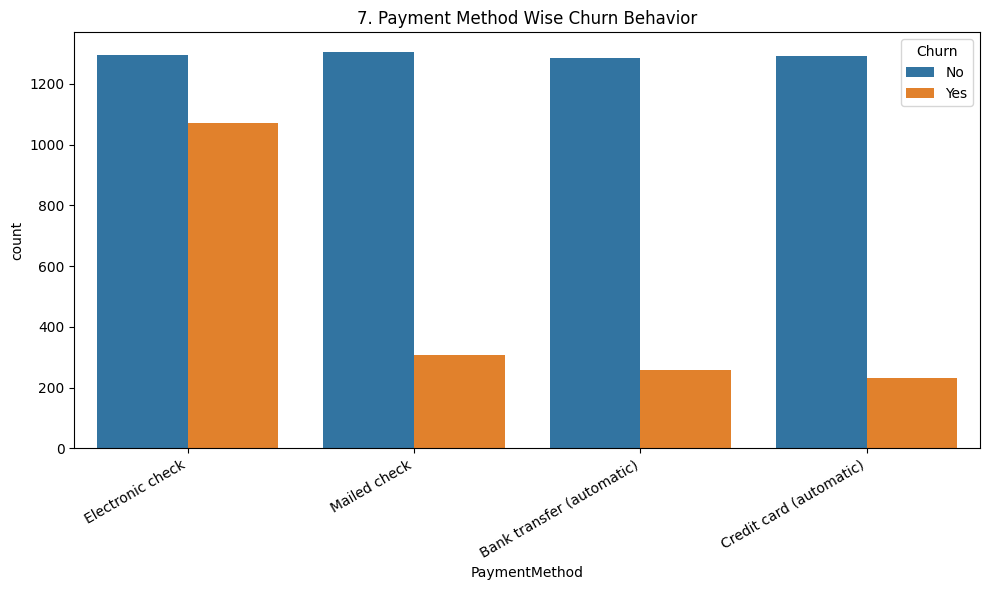

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=30, ha='right')
plt.title(f'{plot_no}. Payment Method Wise Churn Behavior')
show_fig()
plot_no += 1

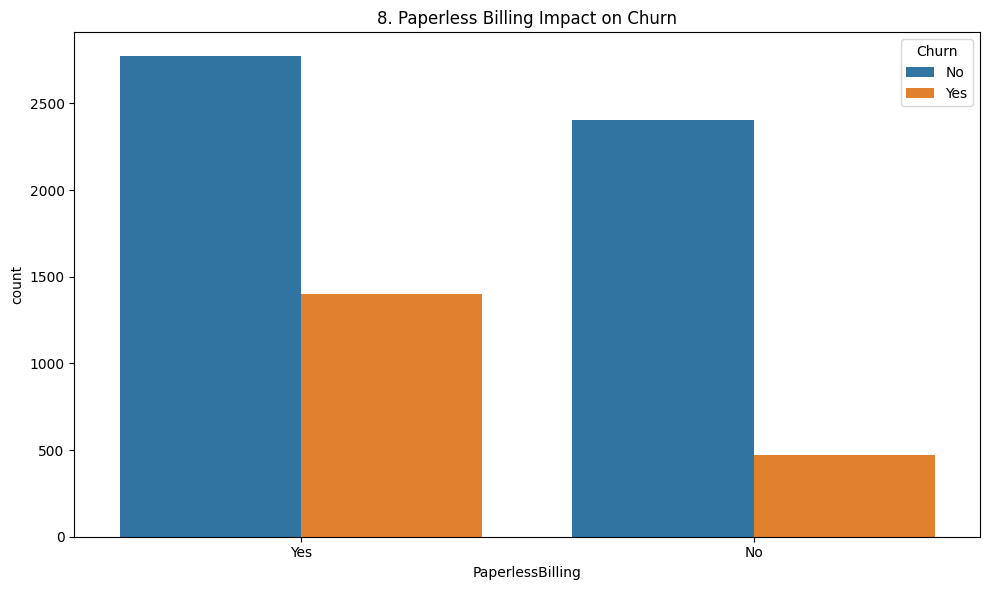

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PaperlessBilling', hue='Churn')
plt.title(f'{plot_no}. Paperless Billing Impact on Churn')
show_fig()
plot_no += 1

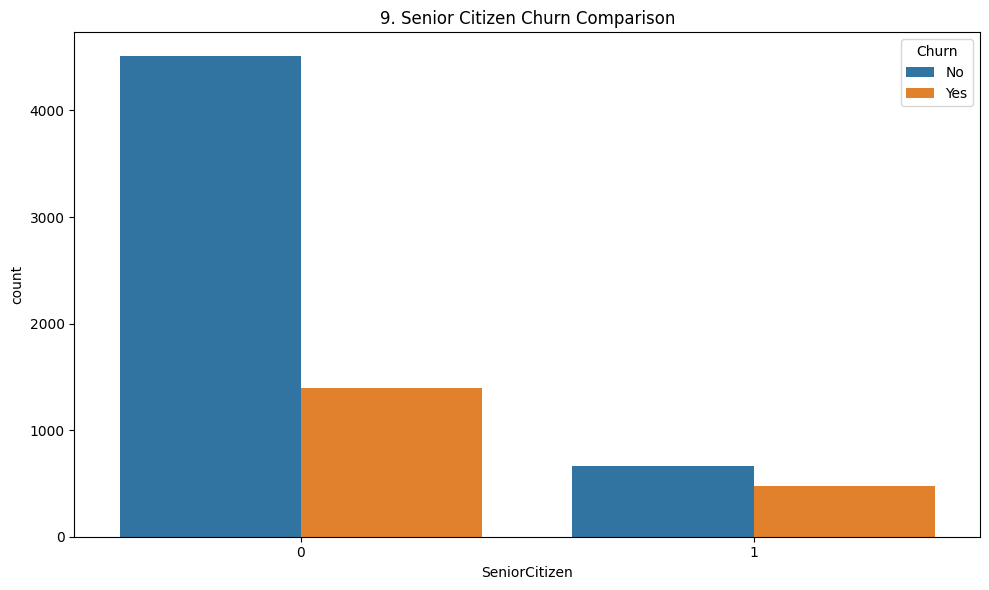

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')
plt.title(f'{plot_no}. Senior Citizen Churn Comparison')
show_fig()
plot_no += 1

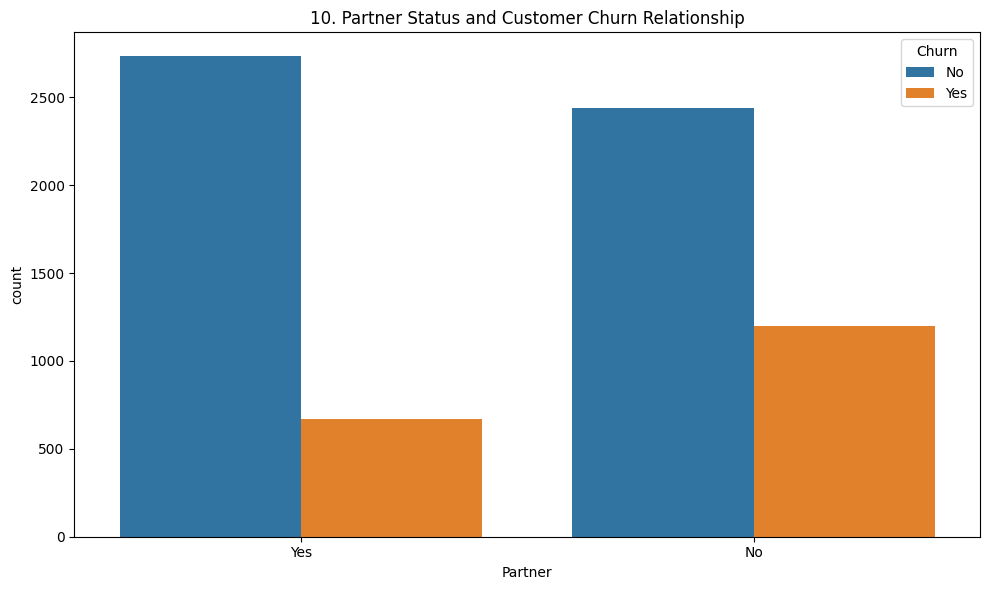

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Partner', hue='Churn')
plt.title(f'{plot_no}. Partner Status and Customer Churn Relationship')
show_fig()
plot_no += 1

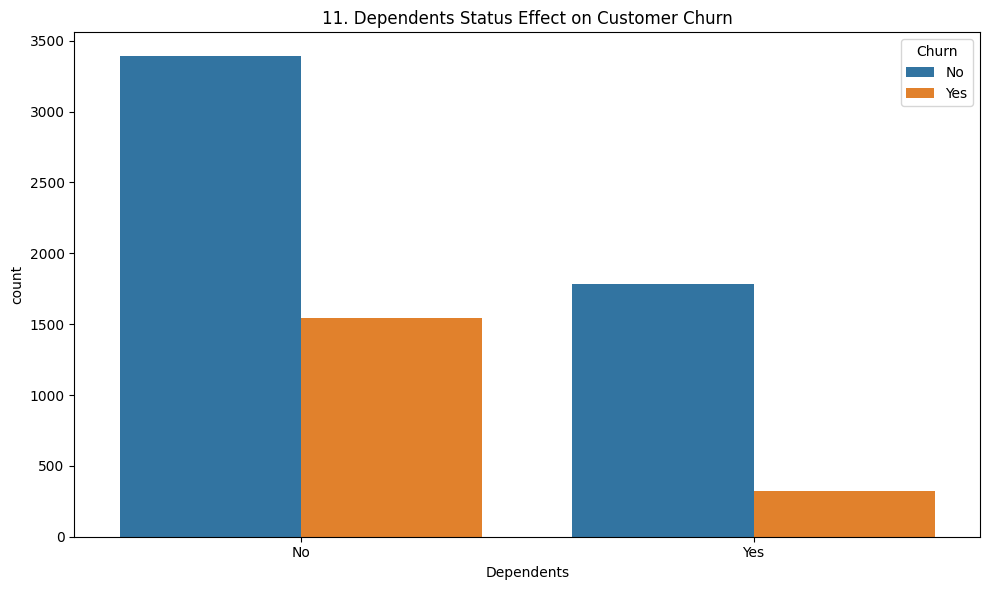

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Dependents', hue='Churn')
plt.title(f'{plot_no}. Dependents Status Effect on Customer Churn')
show_fig()
plot_no += 1

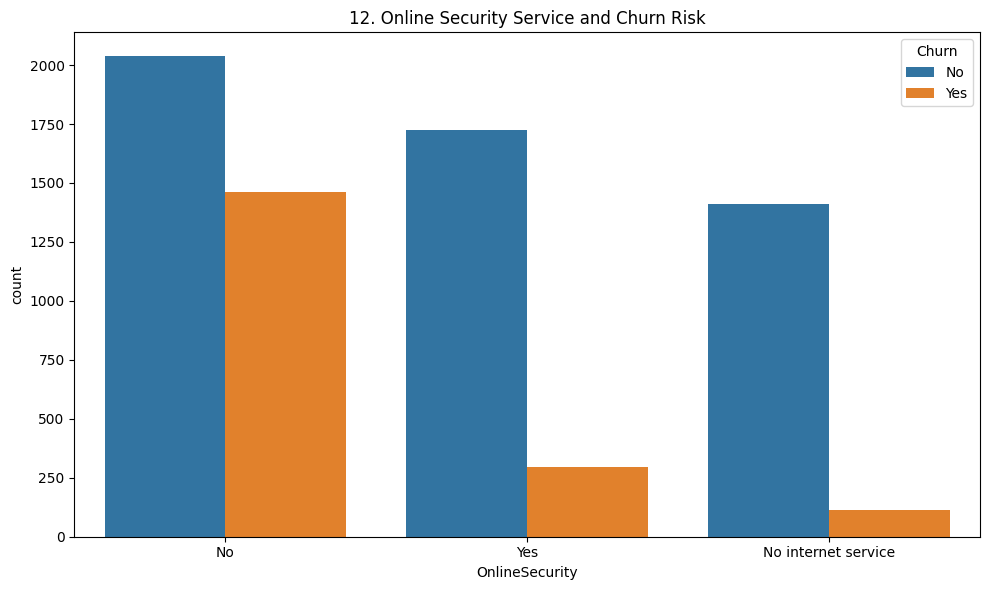

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title(f'{plot_no}. Online Security Service and Churn Risk')
show_fig()
plot_no += 1

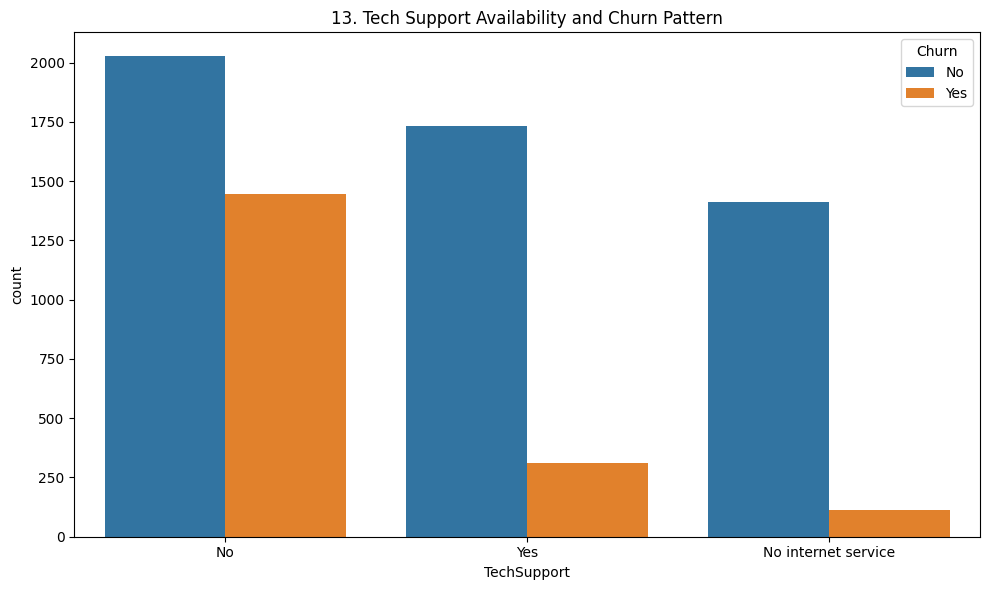

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title(f'{plot_no}. Tech Support Availability and Churn Pattern')
show_fig()
plot_no += 1

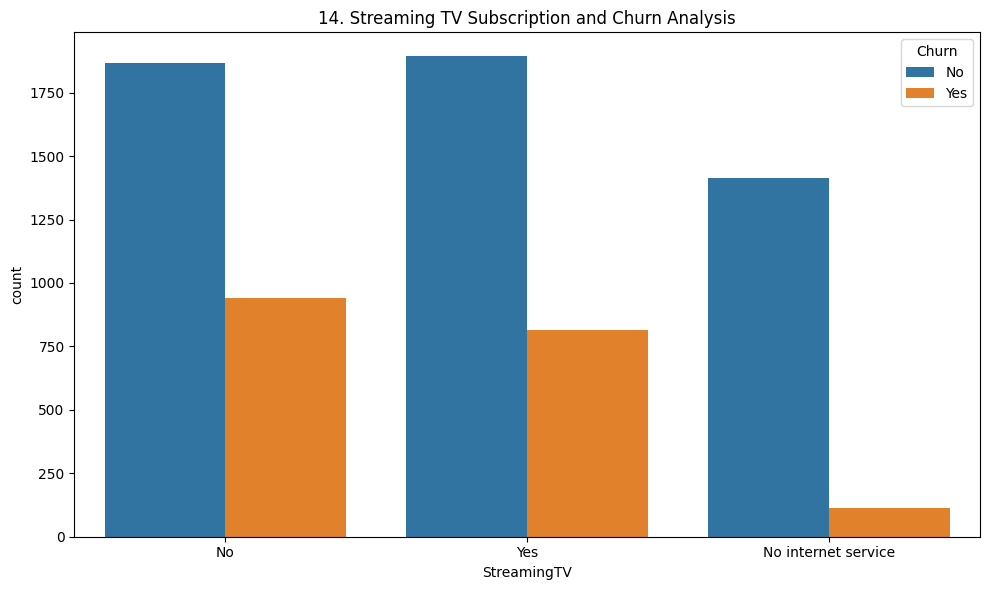

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='StreamingTV', hue='Churn')
plt.title(f'{plot_no}. Streaming TV Subscription and Churn Analysis')
show_fig()
plot_no += 1

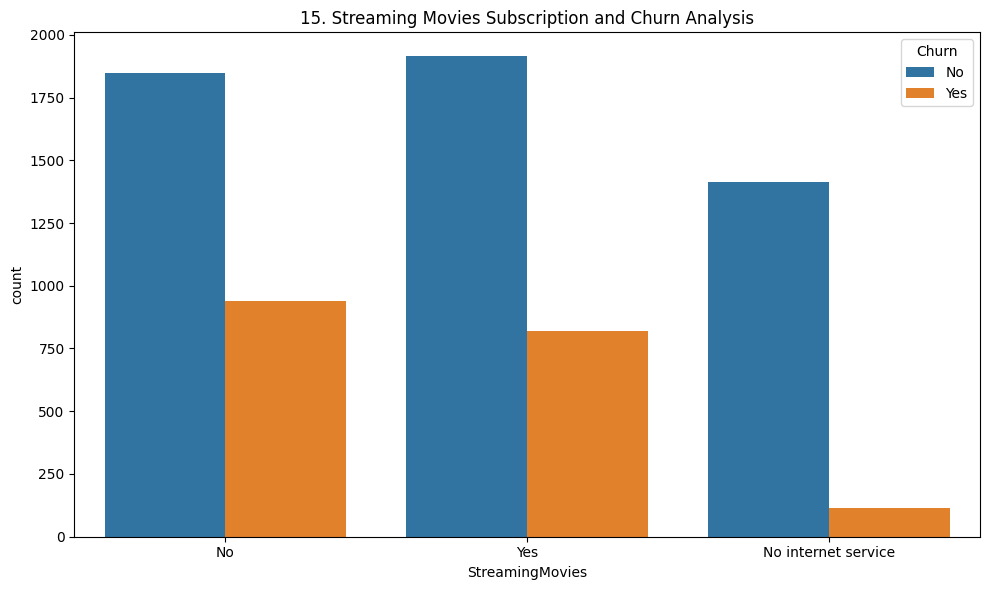

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='StreamingMovies', hue='Churn')
plt.title(f'{plot_no}. Streaming Movies Subscription and Churn Analysis')
show_fig()
plot_no += 1

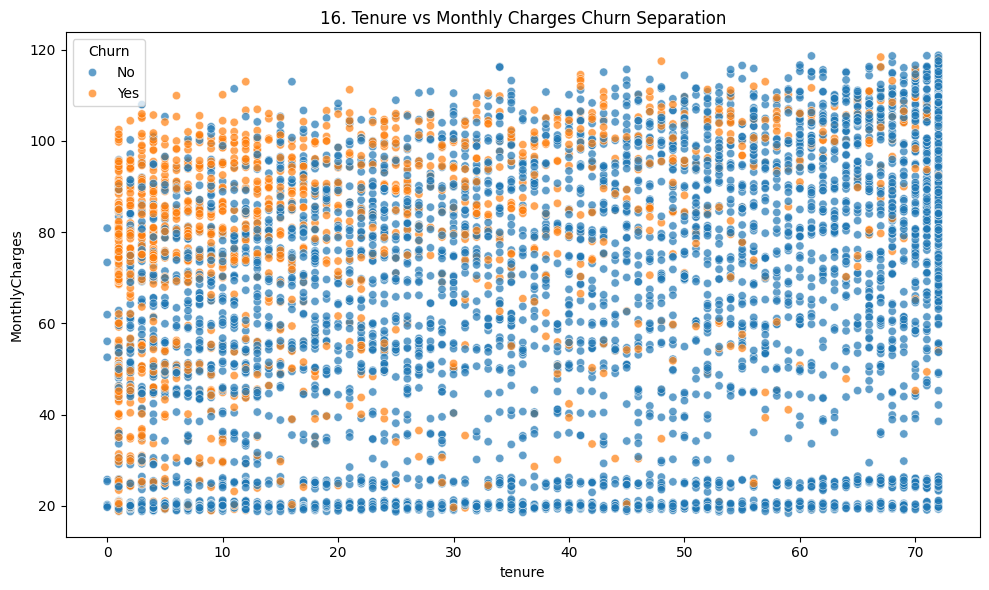

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.7)
plt.title(f'{plot_no}. Tenure vs Monthly Charges Churn Separation')
show_fig()
plot_no += 1

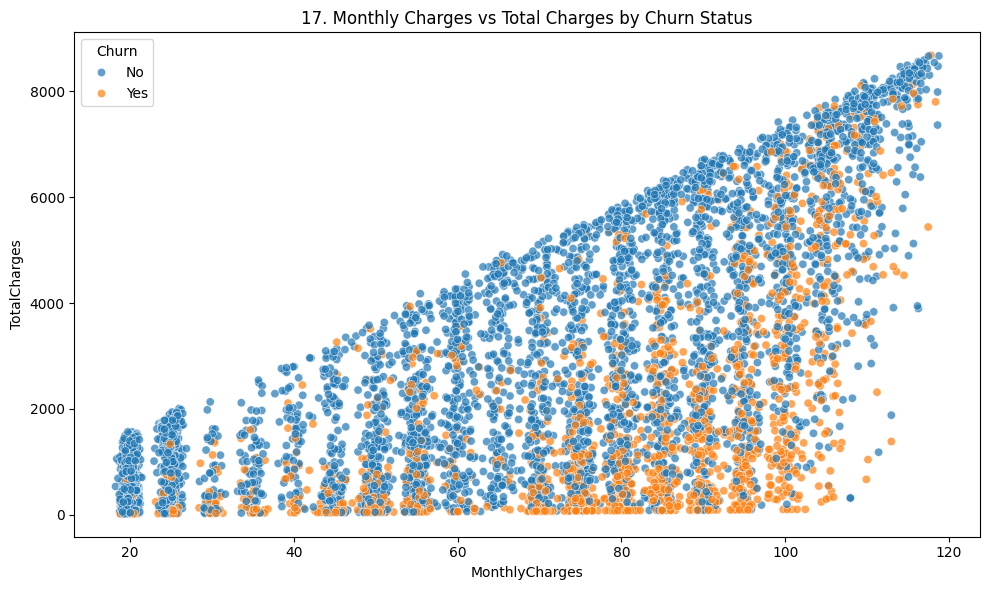

In [29]:
fig = plt.figure(figsize=(10,6))
temp_df = df.copy()
temp_df['TotalCharges'] = pd.to_numeric(temp_df['TotalCharges'], errors='coerce')
sns.scatterplot(data=temp_df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.7)
plt.title(f'{plot_no}. Monthly Charges vs Total Charges by Churn Status')
show_fig()
plot_no += 1

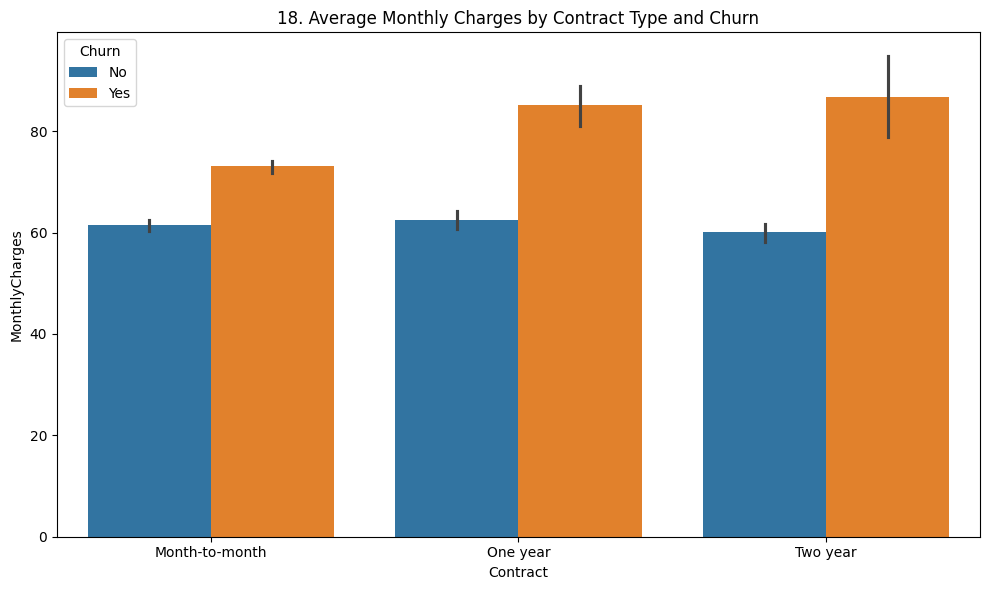

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn', estimator='mean')
plt.title(f'{plot_no}. Average Monthly Charges by Contract Type and Churn')
show_fig()
plot_no += 1

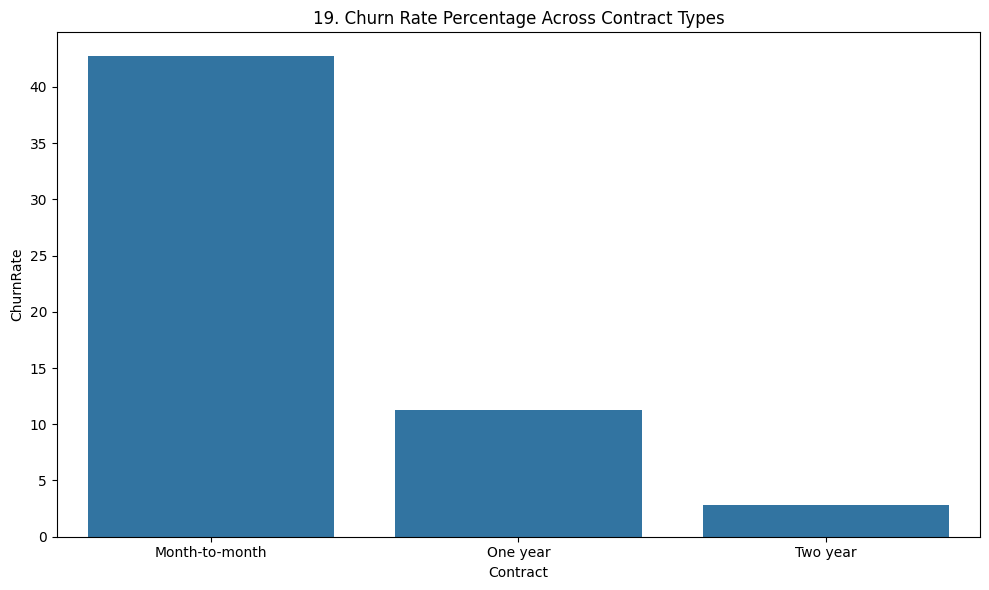

In [31]:
fig = plt.figure(figsize=(10,6))
churn_rate = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='ChurnRate')
sns.barplot(data=churn_rate, x='Contract', y='ChurnRate')
plt.title(f'{plot_no}. Churn Rate Percentage Across Contract Types')
show_fig()
plot_no += 1

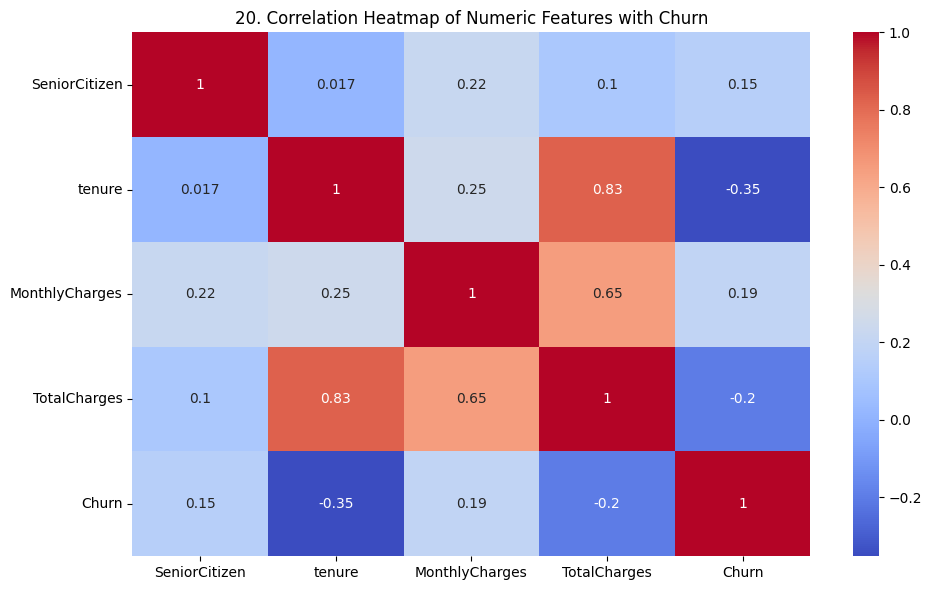

In [32]:
fig = plt.figure(figsize=(10,6))
corr_df = df.copy()
corr_df['TotalCharges'] = pd.to_numeric(corr_df['TotalCharges'], errors='coerce')
corr_df['Churn'] = corr_df['Churn'].map({'Yes': 1, 'No': 0})
corr = corr_df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numeric Features with Churn')
show_fig()
plot_no += 1

# Model Training

## copy dataframe

In [33]:
data = df.copy()

## convert TotalCharges into numeric

In [34]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

## fill missing values

In [35]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())

## remove customerID

In [36]:
data = data.drop('customerID', axis=1)

## convert target column

In [37]:
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

## separate features and target

In [38]:
X = data.drop('Churn', axis=1)
y = data['Churn']

## split dataset

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## get categorical column indexes

In [40]:
cat_features = X.select_dtypes(include='object').columns
cat_indexes = [X.columns.get_loc(col) for col in cat_features]

## train model

In [41]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=0
)

model.fit(X_train, y_train, cat_features=cat_indexes)

CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='Logloss', verbose=0)

## prediction

In [42]:
y_pred = model.predict(X_test)

## accuracy score

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.7977288857345636


## classification report

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



## confusion matrix

In [45]:
cm = confusion_matrix(y_test, y_pred)

## plot confusion matrix

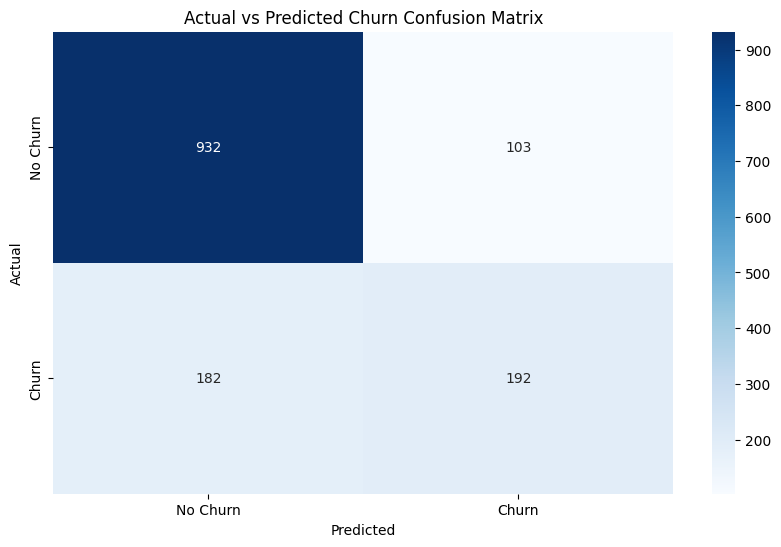

In [46]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Actual vs Predicted Churn Confusion Matrix")
plt.show()